In [13]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [4]:
T_MC_R01 = np.array([8.5,12,15,19.9,24.8])
P_MC_R01 = np.array([0,1.25e-6,2.75e-6,6e-6,9.5e-6])

T_MC_R27 = np.array([14.1,15,20,25,30,35,40,45,50,55,60,65,70,75,85,95,105])
P_MC_R27 = np.array([0,4e-7,4.1e-6,7.3e-6,10.8e-6,14.9e-6,20.7e-6,28.1e-6,36.5e-6,47e-6,60.3e-6,73.4e-6,85.3e-6,100.2e-6\
                                ,140.3e-6,178.1e-6,241.2e-6])

T_MC_R26 = np.array([12,15,20,25,30,35,40,45,55,65,75,85,95,105])
P_MC_R26 = np.array([0,1.2e-6,4.7e-6,8e-6,11.2e-6,15.4e-6,21.1e-6,28.3e-6,47.3e-6,73e-6,104e-6,134.4e-6,178.2e-6,244.6e-6])

T_MC_R25 = np.array([35,40,45,50,55,60,65,70,75,80])
P_MC_R25 = np.array([8e-7,6e-6,1.3e-5,2.16e-5,3.26e-5,4.44e-5,5.51e-5,6.85e-5,8.28e-5,9.9e-5])

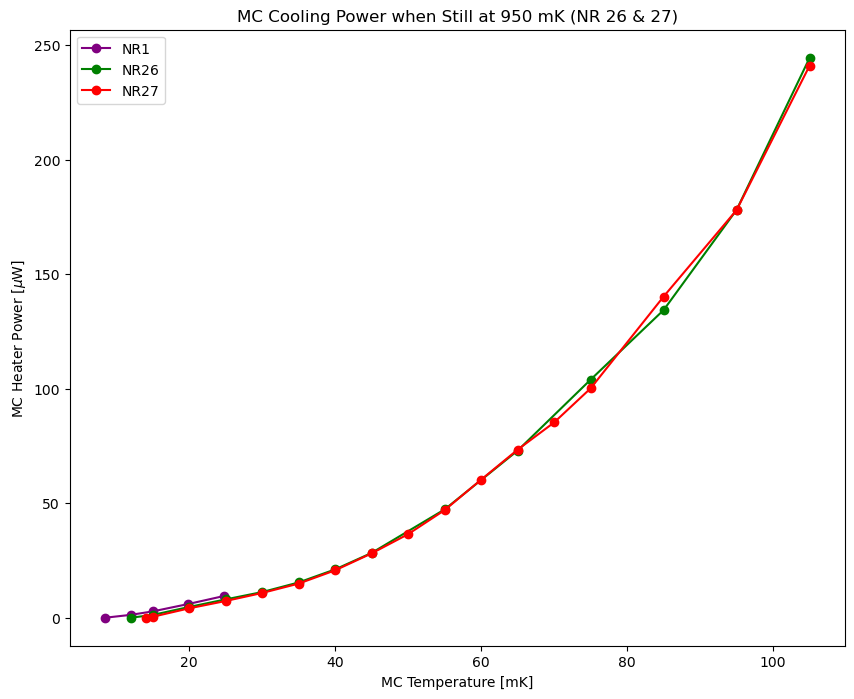

In [8]:
fig = plt.figure(figsize=(10,8))
ax0 = fig.gca()
ax0.set_title("MC Cooling Power when Still at 950 mK (NR 26 & 27)")
ax0.set_xlabel("MC Temperature [mK]")
ax0.set_ylabel("MC Heater Power [$\mu$W]")

ax0.plot(T_MC_R01,P_MC_R01*1e6,label="NR1" ,marker="o",ls="-",color='purple')
ax0.plot(T_MC_R26,P_MC_R26*1e6,label="NR26",marker="o",ls="-",color='green')
ax0.plot(T_MC_R27,P_MC_R27*1e6,label="NR27",marker="o",ls="-",color='red')

ax0.legend()

In [35]:
linear = lambda x,a,b: a*x + b

max_T_mK = 75.0

popt_NR01, pcov_NR01 = curve_fit(linear,np.power(1e-3*T_MC_R01[T_MC_R01<=max_T_mK],2),P_MC_R01[T_MC_R01<=max_T_mK]*1e3)
popt_NR26, pcov_NR26 = curve_fit(linear,np.power(1e-3*T_MC_R26[T_MC_R26<=max_T_mK],2),P_MC_R26[T_MC_R26<=max_T_mK]*1e3)
popt_NR27, pcov_NR27 = curve_fit(linear,np.power(1e-3*T_MC_R27[T_MC_R27<=max_T_mK],2),P_MC_R27[T_MC_R27<=max_T_mK]*1e3)

perr_NR01 = np.sqrt(np.diag(pcov_NR01))
perr_NR26 = np.sqrt(np.diag(pcov_NR26))
perr_NR27 = np.sqrt(np.diag(pcov_NR27))

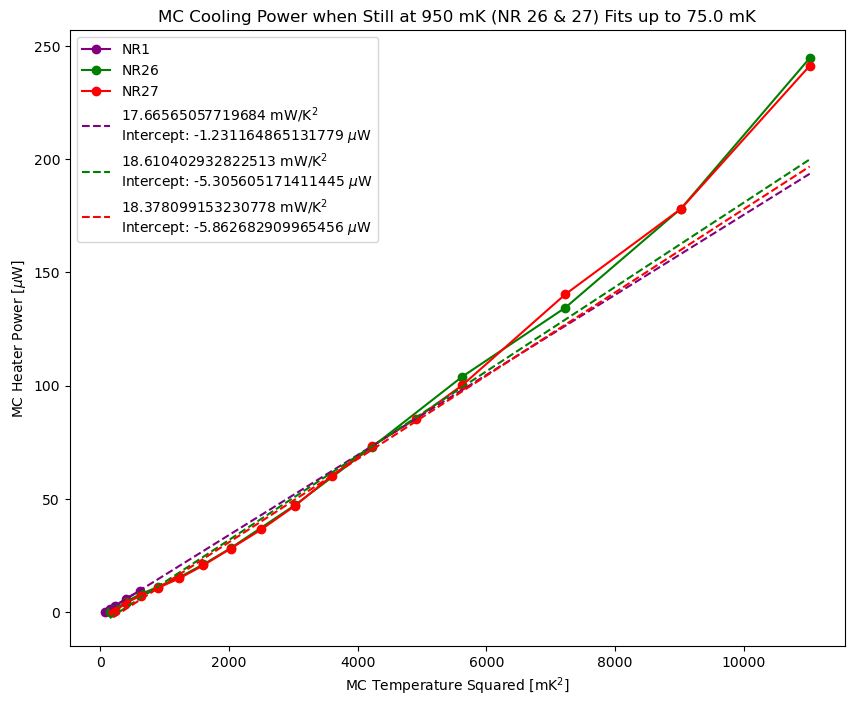

In [36]:
fig = plt.figure(figsize=(10,8))
ax0 = fig.gca()
ax0.set_title("MC Cooling Power when Still at 950 mK (NR 26 & 27) Fits up to "+str(max_T_mK)+" mK")
ax0.set_xlabel("MC Temperature Squared [mK$^2$]")
ax0.set_ylabel("MC Heater Power [$\mu$W]")

ax0.plot(np.power(T_MC_R01,2),P_MC_R01*1e6,label="NR1" ,marker="o",ls="-",color='purple')
ax0.plot(np.power(T_MC_R26,2),P_MC_R26*1e6,label="NR26",marker="o",ls="-",color='green')
ax0.plot(np.power(T_MC_R27,2),P_MC_R27*1e6,label="NR27",marker="o",ls="-",color='red')

ax0.plot(np.power(T_MC_R26,2),1e3*linear(np.power(1e-3*T_MC_R26,2),*popt_NR01),label=str(popt_NR01[0])+" mW/K$^2$\nIntercept: "+str(popt_NR01[1]*1e3)+" $\mu$W",marker="None",ls="--",color='purple')
ax0.plot(np.power(T_MC_R26,2),1e3*linear(np.power(1e-3*T_MC_R26,2),*popt_NR26),label=str(popt_NR26[0])+" mW/K$^2$\nIntercept: "+str(popt_NR26[1]*1e3)+" $\mu$W",marker="None",ls="--",color='green')
ax0.plot(np.power(T_MC_R27,2),1e3*linear(np.power(1e-3*T_MC_R27,2),*popt_NR27),label=str(popt_NR27[0])+" mW/K$^2$\nIntercept: "+str(popt_NR27[1]*1e3)+" $\mu$W",marker="None",ls="--",color='red')

ax0.legend()